In [1]:
import pandas as pd
import numpy as np
import numbers

In [2]:
def find_roundest_ellipse_in_df(df):
    s = df.ratio2
    closest_ind = np.nanargmin(np.abs(s - 1))  # find the index of the value closest to 1
    return int(closest_ind)

def kerr(df, aEC = np.nan, bEC = np.nan):
    if aEC != aEC:
        idx = find_roundest_ellipse_in_df(df)
        dx = df.loc[df.index[idx],'center_x']
        dy = df.loc[df.index[idx],'center_y']
        if not isinstance(dx, numbers.Number):
            dx = dx.iloc[0]
        if not isinstance(dy, numbers.Number):
            dy = dy.iloc[0]
        aEC = int(dx)
        bEC = int(dy)

    theta_values = np.full(len(df), np.nan)  # Initialize theta column with NaNs
    phi_values = np.full(len(df), np.nan)  # Initialize phi column with NaNs
    r_values = np.full(len(df), np.nan)  # Initialize r column with NaNs

    # Convert columns to NumPy arrays for faster access
    hw_values = df['ratio2'].values
    aPC_values = df['center_x'].values
    bPC_values = df['center_y'].values

    # Mask for valid `hw` values (to ignore NaNs)
    valid_mask = ~np.isnan(hw_values)

    # Vectorized computation for `top` and `bot`
    sqrt_component = np.sqrt(1 - hw_values[valid_mask]**2)
    distances = np.sqrt((aPC_values[valid_mask] - aEC)**2 + (bPC_values[valid_mask] - bEC)**2)

    top_values = sqrt_component * distances
    bot_values = (1 - hw_values[valid_mask]**2)

    top = np.sum(top_values)
    bot = np.sum(bot_values)

    f_z = top / bot

    # Compute `r` for all rows where `major_ax` is valid
    valid_major_ax = ~np.isnan(df['major_ax'].values)
    max_axes = np.maximum(df['major_ax'].values, df['minor_ax'].values)
    r_values[valid_major_ax]  = (2 * max_axes[valid_major_ax]) / f_z

    # Compute `theta` and `phi` in a vectorized way
    valid_positions = ~np.isnan(aPC_values) & ~np.isnan(bPC_values)

    # p1 = (aPC_values[valid_positions] - aEC)
    # p = p1/f_z
    comp_p = np.arcsin((aPC_values[valid_positions] - aEC) / f_z)

    # t1 = (bPC_values[valid_positions] - bEC)
    # t2 =  (np.cos(comp_p) * f_z)
    # t = t1/t2
    comp_t = np.arcsin((bPC_values[valid_positions] - bEC) / (np.cos(comp_p) * f_z))

    theta_values[valid_positions] = np.degrees(comp_t)
    phi_values[valid_positions] = np.degrees(comp_p)

    # Create output DataFrame
    output_df = pd.DataFrame({'r': r_values, 'theta': theta_values, 'phi': phi_values}, index=df.index)
    output_df = pd.concat([df[['frame', 'x_angle','y_angle','ratio2','ratio1']],output_df], axis=1)
    return f_z, output_df #, valid_mask, valid_major_ax, valid_positions

In [3]:
sim_df = pd.read_csv(r'Z:\Nimrod\3D_calibration\eye_ellipse_map_diameter_8mm_distance_13mm\ellipse_angle_mapping_correct_diameter_08mm_distance_13mm.csv', index_col=0)
sim_df['major_ax'] = np.maximum(sim_df['axs_1'], sim_df['axs_2'])
sim_df['minor_ax'] = np.minimum(sim_df['axs_1'], sim_df['axs_2'])
sim_df['ratio2'] = sim_df['minor_ax'] / sim_df['major_ax']
sim_df['ratio1'] =  sim_df['major_ax']/sim_df['minor_ax']
_,kerr_df = kerr(sim_df,aEC=640//2, bEC=480//2)

<ipython-input-2-462c7f5326de>:57: RuntimeWarning: invalid value encountered in arcsin
  comp_t = np.arcsin((bPC_values[valid_positions] - bEC) / (np.cos(comp_p) * f_z))


k=70°  →  R=35.00°  →  ratio@R≈0.761
Within-span (r≤R) mean error: 3.242°  (n=4088)


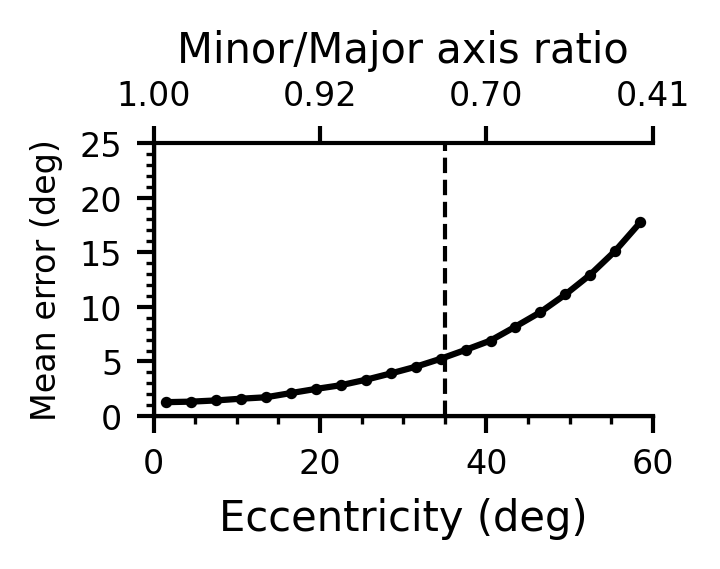

In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_error_vs_ecc_with_ratio_axis_pdf(
    df,
    k=40,                         # span (deg) -> vertical line at R=k/2 on bottom axis
    metric="total",               # "total" | "phi" | "theta"
    r_bins=30,                    # number of eccentricity bins (x points are bin centers)
    r_range=None,                 # (r_min, r_max) in deg for bottom axis, e.g. (0, 60)
    min_per_bin=20,               # drop curve bins with < this many samples
    ring_halfwidth_deg=0.5,       # for reporting ratio at the span ring (optional)
    figsize=(3.8, 2.6),
    dpi=300,
    export_pdf_path=None,
    font_family="Arial",
    y_range=None
):
    """
    Mean angular error vs eccentricity (bottom x-axis in degrees), with a top x-axis
    showing the corresponding ratio (minor/major) learned from the dataset.

    • Curve is computed by binning on eccentricity r = hypot(x_angle, y_angle).
      Each plotted point is the mean error in one r-bin, placed at that bin's CENTER.
    • Bottom x-axis extent is controlled via r_range=(r_min, r_max) in degrees.
    • The dashed vertical line is drawn at R = k/2 on the degree axis.
    • The top x-axis labels (ratio) are computed from the dataset by taking the
      median ratio in each r-bin and interpolating to the bottom tick positions.
    • PDF export uses TrueType fonts (editable text); Arial if available.
    """
    # ---------- Fonts (editable text in PDF) ----------
    from matplotlib import rcParams
    %matplotlib inline
    plt.style.use('default')
    rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded and editable
    rcParams['ps.fonttype'] = 42  # Ensure compatibility with vector outputs

    # ---------- Data prep ----------
    req = {"ratio2","x_angle","y_angle","phi","theta"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    d = df[list(req)].copy().dropna(subset=list(req))
    d["ratio2"] = pd.to_numeric(d["ratio2"], errors="coerce").clip(0.0, 1.0)
    d = d.dropna(subset=["ratio2"])
    d["r_xy"] = np.hypot(d["x_angle"], d["y_angle"])

    # Errors
    d["err_phi"]   = d["phi"]   - d["x_angle"]
    d["err_theta"] = d["theta"] - d["y_angle"]
    if metric == "total":
        d["error"] = np.sqrt(d["err_phi"]**2 + d["err_theta"]**2)
        ylab = "Mean error (deg)"
    elif metric == "phi":
        d["error"] = np.abs(d["err_phi"])
        ylab = "Mean |φ − x_angle| (deg)"
    elif metric == "theta":
        d["error"] = np.abs(d["err_theta"])
        ylab = "Mean |θ − y_angle| (deg)"
    else:
        raise ValueError("metric must be 'total', 'phi', or 'theta'")

    # ---------- Eccentricity binning for the curve ----------
    # Decide axis limits in degrees
    if r_range is None:
        r_min = float(np.nanmin(d["r_xy"]))
        r_max = float(np.nanmax(d["r_xy"]))
    else:
        r_min, r_max = map(float, r_range)

    # Build r-bins across the requested extent (even if edges are empty)
    r_edges = np.linspace(r_min, r_max, int(r_bins) + 1)
    r_cats  = pd.cut(d["r_xy"], r_edges, include_lowest=True)
    centers_r = np.array([iv.mid for iv in r_cats.cat.categories])

    # Aggregate per r-bin: mean error, n, and median ratio (for top-axis mapping)
    gb = d.groupby(r_cats, observed=False).agg(
        mean_error=("error","mean"),
        n=("error","size"),
        ratio_med=("ratio2","median"),
    ).reset_index(drop=True)
    gb = gb.assign(r_center=centers_r)

    # Curve points (drop sparse bins)
    curve = gb[gb["n"] >= int(min_per_bin)].copy()

    # ---------- Span line at R = k/2 (degrees) ----------
    R = float(k) / 2.0

    # For reporting only: dataset-based ratio at that ring (use ring or fallback to interp)
    ring_mask = np.abs(d["r_xy"] - R) <= float(ring_halfwidth_deg)
    if ring_mask.any():
        ratio_at_R = float(d.loc[ring_mask, "ratio2"].mean())
    else:
        # Fallback: interpolate from r-bin medians
        valid = gb["n"].to_numpy() > 0
        ratio_at_R = float(np.interp(R, gb.loc[valid, "r_center"], gb.loc[valid, "ratio_med"]))

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Draw the curve (points are at r-bin CENTERS)
    ax.plot(curve["r_center"], curve["mean_error"], linewidth=1.5, color="black")
    ax.scatter(curve["r_center"], curve['mean_error'],s=3,color='black')

    # Bottom axis (degrees)
    if y_range is not None: ax.set_ylim(*y_range)
    ax.set_xlim(r_min, r_max)
    ax.set_xlabel("Eccentricity (deg)", fontsize=10)
    ax.set_ylabel(ylab, fontsize=8)
    ax.tick_params(axis="both", labelsize=8, width=1.0, length=4, direction="out")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", width=0.8, length=2, direction="out")
    ax.yaxis.set_major_locator(MaxNLocator(5))
    for spine in ("left","bottom"):
        ax.spines[spine].set_visible(True); ax.spines[spine].set_linewidth(1.0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    # Vertical span line at R (degrees)
    ax.axvline(R, linestyle="--", linewidth=1.0, color="black")

    # Top x-axis: ratio at the same degree ticks
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())  # share transform
    # Use the actual bottom ticks so both axes align
    bottom_ticks = ax.get_xticks()
    # Interpolate ratio from r_center → ratio_med over bins with data
    valid_map = gb["n"].to_numpy() > 0
    r_map  = gb.loc[valid_map, "r_center"].to_numpy()
    q_map  = gb.loc[valid_map, "ratio_med"].to_numpy()
    ratio_labels = np.interp(bottom_ticks, r_map, q_map,
                             left=q_map[0] if q_map.size else np.nan,
                             right=q_map[-1] if q_map.size else np.nan)
    ax_top.set_xticks(bottom_ticks)
    ax_top.set_xticklabels([f"{v:.2f}" if np.isfinite(v) else "" for v in ratio_labels], fontsize=8)
    ax_top.set_xlabel("Minor/Major axis ratio", fontsize=10)
    ax_top.tick_params(axis="x", width=1.0, length=4, direction="out")
    ax_top.spines["top"].set_visible(True); ax_top.spines["top"].set_linewidth(1.0)
    ax_top.spines["right"].set_visible(False)

    plt.tight_layout()

    # ---------- Export ----------
    if export_pdf_path:
        fig.savefig(export_pdf_path, bbox_inches="tight")
        print(f"Saved PDF → {export_pdf_path}")

    # ---------- Brief report ----------
    in_span = d["r_xy"] <= R

    mean_span = float(d.loc[in_span, "error"].mean()) if in_span.any() else np.nan

    print(f"k={k:g}°  →  R={R:.2f}°  →  ratio@R≈{ratio_at_R:.3f}")
    print(f"Within-span (r≤R) mean error: {mean_span:.3f}°  (n={int(in_span.sum())})")

    return {
        "curve": curve[["r_center","mean_error","n","ratio_med"]].reset_index(drop=True),
        "r_limits": (r_min, r_max),
        "R": R,
        "ratio_at_R": ratio_at_R,
        "within_span_mean": mean_span,
    }

export_path = r'Z:\\Nimrod\\Paper_Figures\\2024_Personalized_headstage_eye_tracking\\supplementary\\kerr_accuracy_report_span60_ylim0_25.pdf'
out = plot_error_vs_ecc_with_ratio_axis_pdf(
    kerr_df,
    k=70,
    metric="total",
    r_bins=20,
    r_range=(0, 60),            # force 0..60° on bottom axis
    min_per_bin=0,
    ring_halfwidth_deg=0.5,
    figsize=(2.5, 2),
    dpi=300,
    export_pdf_path=None,
    font_family="Arial",
    y_range=(0,25)
)
